---
 Title: Week 6 - Data Scaling and Working with Dataframes         
 Author: Tres Reeves  
 Date: 19 July 2026  
 Description: Learning to scale data and how to work with Dataframes

---
---
 Title: pandas.DataFrame.dropna          
 Author: Pandas Development Team            
 Date: Not Dated          
 Description: Reference for the dropna() method to remove missing values.                 
 URL: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html     

---
---
 Title: pandas.DataFrame.apply        
 Author: Pandas Development Team         
 Date: Not Dated            
 Description: Reference to use the apply() method, which runs a function along the axis of a dataFrame       
 URL: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.apply.html            

---
---
 Title: numpy.std        
 Author: Numpy Developers         
 Date: Not Dated            
 Description: Reference on using the std() function, inlcuding the ddof parameter.          
 URL: https://numpy.org/doc/stable/reference/generated/numpy.std.html                 

---

In [4]:
# Importing libaries needed 
import numpy as np 
import pandas as pd 

**Part 1: Data Normlization** 

- Build a Python function that takes in a vector (array) and normalizes it.

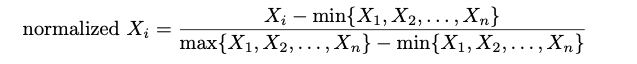

In [5]:
# Normalize formula function 
def normalize(x):
    x = np.array(x, dtype=float)
    return (x - np.min(x)) / (np.max(x) - np.min(x))

**Part 2: Data Standardization** 

- Build a Python function that takes in a vector (array) and standardizes it.

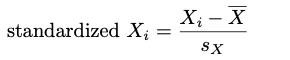

In [6]:
# Standardized formula function 
def standardize(x):
    x = np.array(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x, ddof=1)) # Ddof = delta degrees of freedom 

**Part 3: Working with a DataFrame** 

Data set from https://www.kaggle.com/camnugent/california-housing-prices?select=housing.csv

**(a) Rows of data**

- How many rows does this data set have?

In [7]:
# Reading calif_housing_data.csv 
house_data = pd.read_csv('calif_housing_data.csv')

# Pulling rows and columns from house data
row_count = house_data.shape 

# Printing number of rows
print(row_count[0])

20640


**(b) Target Vector**

- What is the target vector for your model?

In [8]:
t_vector = house_data['median_house_value']

# Housing data headers
print(house_data.columns)
print("---------------------------------")
print("\nBased on the headers, I believe the target vector is median_house_value\n")
print(t_vector)

Index(['housing_median_age', 'total_bedrooms', 'households', 'median_income',
       'median_house_value'],
      dtype='str')
---------------------------------

Based on the headers, I believe the target vector is median_house_value

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64


**(c) New Feature**

- Create a new feature by taking the total bedrooms divided by the number of households. What
does this new feature represent?

**Answer:**
This data represent the average been total bedrooms per household. 

In [9]:
# Dropping NaN data as its causing bedroom_hosuehold_avg to have NaN when standardized
house_data = house_data.dropna(subset=['total_bedrooms'])

# Creating the bedroom_household_avg 
house_data['bedroom_household_avg'] = house_data['total_bedrooms'] / house_data['households']

# view of bedroom_household_avg
house_data.head()

,housing_median_age,total_bedrooms,households,median_income,median_house_value,bedroom_household_avg
0,41,129.0,126,8.3252,452600.0,1.023810
1,21,1106.0,1138,8.3014,358500.0,0.971880
2,52,190.0,177,7.2574,352100.0,1.073446
3,52,235.0,219,5.6431,341300.0,1.073059
4,52,280.0,259,3.8462,342200.0,1.081081


**(d) New DataFrame**

- Now, create a new data frame that has three features: the median age, median income, and the
new feature created in part (c).

In [10]:
# Setting up the new DataFrame with three features.
three_feature_df = house_data[['housing_median_age', 'median_income', 'bedroom_household_avg']]

# View of the three_feature_df
three_feature_df.head()

,housing_median_age,median_income,bedroom_household_avg
0,41,8.3252,1.023810
1,21,8.3014,0.971880
2,52,7.2574,1.073446
3,52,5.6431,1.073059
4,52,3.8462,1.081081


**(e) Applying Standardization**

- Take the data frame created in part (d) and apply data standardization to the features.

In [11]:
# Applying the standardization forumla from above 
three_feature_df.apply(standardize)

print(three_feature_df.apply(standardize))

print("----------------------------------------")
# Checking data 
print(three_feature_df.apply(standardize).mean())
print(three_feature_df.apply(standardize).std())

       housing_median_age  median_income  bedroom_household_avg
0                0.982139       2.345106              -0.153859
1               -0.606195       2.332575              -0.262930
2                1.855723       1.782896              -0.049603
3                1.855723       0.932947              -0.050416
4                1.855723      -0.013143              -0.033567
...                   ...            ...                    ...
20635           -0.288528      -1.216697               0.076183
20636           -0.844446      -0.692027               0.459410
20637           -0.923862      -1.143143               0.048372
20638           -0.844446      -1.055110               0.157229
20639           -1.003279      -0.780587               0.136949

[20433 rows x 3 columns]
----------------------------------------
housing_median_age       0.000000e+00
median_income           -1.557887e-16
bedroom_household_avg    9.458602e-17
dtype: float64
housing_median_age       1.0
median_